In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [2]:
df = pd.read_csv('data/demand_forecasting.csv')

In [12]:
df.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition      object
Promotion               int64
Competitor Pricing    float64
Seasonality            object
Epidemic                int64
Demand                  int64
dtype: object

In [3]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

### Feature Selection ###

In [5]:
features = [
    'Category',
    'Inventory Level',
    'Price',
    'Discount',
    'Promotion',
    'Competitor Pricing'
]

In [6]:
X = df[features].copy()

In [7]:
X

,Category,Inventory Level,Price,Discount,Promotion,Competitor Pricing
0,Electronics,195,72.72,5,0,85.73
1,Clothing,117,80.16,15,1,92.02
2,Clothing,247,62.94,10,1,60.08
3,Electronics,139,87.63,10,0,85.19
4,Groceries,152,54.41,0,0,51.63
...,...,...,...,...,...,...
75995,Toys,233,29.80,5,0,32.23
75996,Toys,137,42.92,5,0,40.73
75997,Clothing,197,17.81,10,0,19.41
75998,Furniture,125,151.72,0,0,143.71


In [8]:
y = df['Demand']

In [9]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

### Encoding ###

In [10]:
label_encoders = {}

In [15]:
categorycal_cols = X.select_dtypes(include='object').columns

In [16]:
categorycal_cols

Index(['Category'], dtype='object')

In [17]:
for col in categorycal_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [18]:
label_encoders

{'Category': LabelEncoder()}

### Model training ###

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [34]:
xgb = XGBRegressor(objective='reg:squarederror',  n_jobs=-1)

In [35]:
params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [36]:
xgb_rand = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter= 25,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

In [37]:
xgb_rand.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,25
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [38]:
xgb_rand.best_params_

{'subsample': 0.8,
 'n_estimators': 500,
 'min_child_weight': 5,
 'max_depth': 8,
 'learning_rate': 0.01,
 'colsample_bytree': 1.0}

In [39]:
best_model = xgb_rand.best_estimator_

### Predict ###

In [40]:
y_pred = best_model.predict(X_test)

In [51]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(35.978095278151535)

In [52]:
best_model.feature_importances_

array([0.19051011, 0.01122424, 0.04913408, 0.01117584, 0.7248092 ,
       0.01314645], dtype=float32)

In [55]:
feature_impotance = pd.Series(
    best_model.feature_importances_,
    X.columns
).sort_values(ascending=False)

In [56]:
feature_impotance

Promotion             0.724809
Category              0.190510
Price                 0.049134
Competitor Pricing    0.013146
Inventory Level       0.011224
Discount              0.011176
dtype: float32

<Axes: title={'center': 'Feature Importance'}>

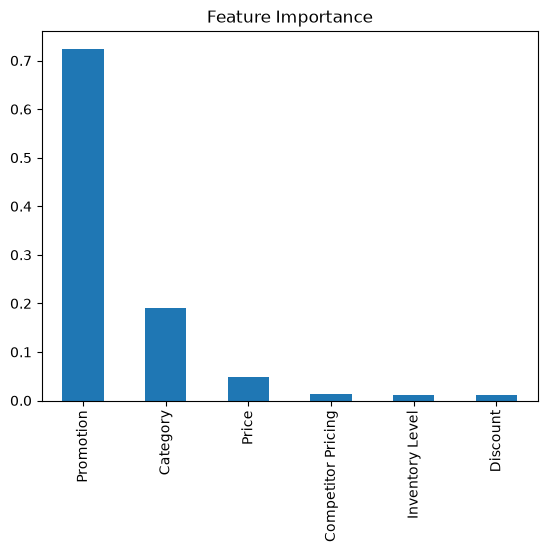

In [58]:
feature_impotance.plot(kind='bar', title='Feature Importance')

In [59]:
import os
import pickle

os.makedirs('encoders', exist_ok=True)

with open('encoders/Category_encoder.pkl', 'wb') as file:
    pickle.dump(label_encoders, file)

In [60]:
os.makedirs('models', exist_ok=True)

with open('models/best_demand_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)